# 09. Three-Agent 패턴 — Planner / Generator / Evaluator

> **왜 Three-Agent 구조가 필요한가요?**
>
> 단일 ReAct 에이전트로 장시간(수십 분~수 시간) 자율 작업을 돌리면 중간 단계에서 품질이 흔들리고, 자기 자신의 산출물을 객관적으로 평가하지 못해요. Anthropic이 2026년 4월 공개한 [Three-Agent Harness](https://www.anthropic.com/engineering/harness-design-long-running-apps) 구조는 **Planner → Generator → Evaluator**로 역할을 명시적으로 분리하고, 각 스프린트마다 **계약(contract)** 을 체결해서 평가 기준을 사전에 합의해요. 이 패턴은 Anthropic 내부 frontend 자동개발 시스템에서 멀티시간 자율 코딩 세션을 가능하게 한 핵심 구조예요.

> 🔑 **비유**: 단일 에이전트가 **혼자 글 쓰고 혼자 채점하는 학생**이라면, 이 3-에이전트 패턴은 **편집자(Planner) + 작가(Generator) + 평론가(Evaluator)** 의 출판사 워크플로우예요. 평론가가 따로 있어야 작가가 구체적으로 무엇을 고쳐야 할지 알 수 있어요.

> **이 노트북이 다루는 신뢰성 차원**: Constrain + Inform + Verify + Correct (실전 통합)
>
> - **Constrain**: Sprint contract로 산출물의 형식·길이·필수 요소를 사전 제한해요
> - **Inform**: Planner의 spec이 Generator에게 충분한 맥락을 전달해요
> - **Verify**: Evaluator가 별도 모델·별도 프롬프트로 객관 채점해요
> - **Correct**: 점수 미달 시 feedback을 받아 Generator가 재시도해요
>
> 이 네 차원이 한 그래프 안에서 한꺼번에 작동하기 때문에 장기 실행 에이전트의 신뢰성이 크게 올라가요.

## 학습 목표

이 노트북을 마치면 다음을 할 수 있어요:

1. 3-agent 패턴(Planner / Generator / Evaluator)의 동기와 구조를 설명할 수 있어요
2. LangGraph의 `StateGraph` + 노드 분리로 역할별 에이전트를 subgraph 친화적으로 구현할 수 있어요
3. **Sprint contract** 를 정의해 단계 간 합의를 형식(JSON-like dict)으로 고정할 수 있어요
4. GAN-style 평가 루프(Generator ↔ Evaluator)를 조건부 엣지로 구현할 수 있어요
5. "Context anxiety" 현상과 long retry loop에서의 **context reset 전략**을 적용할 수 있어요

## 사전 준비

- `03_Thinking_in_LangGraph/03-Reliability-Engineering` — 5가지 사고 도구(Constrain·Inform·Verify·Correct·HITL) 중 이 노트북이 집중하는 Constrain·Inform·Verify·Correct 네 가지
- `09_Multi_Agent` — 역할별 에이전트 분리·핸드오프 패턴
- `10_Deep_Agents/06-Agent-Harness-Patterns.ipynb` — Plan / Delegate / Verify 관점의 하네스 선택 기준
- `12_Testing/03-Generator-Evaluator-Verification` — Generator/Evaluator를 왜 분리해야 하는지, computational·inferential 검증을 어떻게 구분하는지. 이 노트북의 **3-agent 구조는 거기서 배운 2-node GAN 루프에 Planner + Sprint contract를 얹은 확장판**이에요.
- LangGraph `StateGraph`, `add_conditional_edges`, `with_structured_output` 사용 경험

> 📚 **참고 문서**
> - Anthropic, [Harness design for long-running apps](https://www.anthropic.com/engineering/harness-design-long-running-apps) (2026-04)
> - InfoQ, [Anthropic Three-Agent Harness](https://www.infoq.com/news/2026/04/anthropic-three-agent-harness-ai/) (2026-04)
> - LangGraph, [Use the graph API](https://docs.langchain.com/oss/python/langgraph/use-graph-api.md)

> 🧭 **Part 10 연결**: Three-Agent 패턴은 Part 10 bridge의 **Plan / Delegate / Verify**를 가장 명시적으로 펼친 구조예요. Planner는 목표를 실행 가능한 spec으로 바꾸고, Generator는 산출물을 만들며, Evaluator는 독립 기준으로 검증해 장기 실행 중 품질이 흐트러지는 문제를 줄입니다.


## 환경 설정

In [1]:
# ---------------------------------------------------
# 환경 설정
# ---------------------------------------------------
# .env 파일에서 OPENAI_API_KEY 등을 불러와요
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
# ---------------------------------------------------
# LangSmith 추적 (선택)
# ---------------------------------------------------
# 3-agent 패턴은 노드가 많아 LangSmith 추적이 디버깅에 큰 도움이 돼요
import os

# os.environ["LANGCHAIN_TRACING_V2"] = "true"
# os.environ["LANGCHAIN_PROJECT"] = "LangGraph-Three-Agent-Pattern"

## 1. 패턴 개요

Anthropic은 멀티시간 자율 frontend 코딩 시스템을 만들면서 **단일 에이전트로는 품질이 발산**하는 문제를 발견했어요. 최종적으로 도달한 구조가 다음의 3-agent 아키텍처예요.

```
┌─────────┐   spec    ┌──────────┐   contract   ┌───────────┐   draft   ┌────────────┐
│ Planner │ ────────► │ Contract │ ───────────► │ Generator │ ────────► │ Evaluator  │
└─────────┘           └──────────┘              └───────────┘           └─────┬──────┘
                                                       ▲                     │
                                                       │       feedback      │
                                                       └─────────────────────┘
                                                              (retry)
                                                                              │ score≥80
                                                                              ▼
                                                                            done
```

> 💬 **Anthropic 인용** (Harness design for long-running apps, 2026-04):
>
> *"The final result was a three-agent architecture — planner, generator, and evaluator — that produced rich full-stack applications over multi-hour autonomous coding sessions."*

> 💬 **Generator/Evaluator 분리 이유**:
>
> *"Separating the agent doing the work from the agent judging it proves to be a strong lever... the generator has something concrete to iterate against."*

이 인용에서 핵심은 **외부 피드백이 구체적**이 된다는 점이에요. 같은 모델이 자기 작업을 평가하면 "좋아 보인다"는 식의 모호한 자기긍정에 빠지지만, 별도 인스턴스가 별도 프롬프트로 채점하면 "min_length 미달", "섹션 2개 누락" 같은 **반복 가능한 구체적 기준**이 생겨요.

## 2. 시나리오 정의

**태스크**: 주어진 주제로 **마크다운 기술 블로그 포스트** 를 작성한다.

- 산출물 형태: `# 제목` + 3개 `## 섹션` + `## 결론`
- 충분히 작아서 노트북 안에서 수 분 내에 실행 가능
- 충분히 복잡해서 평가 축(디자인 / 독창성 / craft / 기능성)이 의미 있어요
- 코드 생성·보고서 작성·설계 문서 검토 등 **현업 패턴의 축소판**으로 활용 가능

> 🎯 **강의 포인트**: 시나리오를 작게 잡아도 패턴 자체는 동일해요. 13장 캡스톤에서 같은 구조를 코드 생성 / 데이터 변환 파이프라인 등으로 확장해요.

## 3. State 정의

Harness 전체 실행을 담을 `HarnessState`를 정의해요. `history`만 누적이고, `spec` / `contract` / `draft` / `review`는 매 노드가 덮어써요.

| 필드 | 역할 | 누적 여부 |
|------|------|----------|
| `topic` | 사용자 입력 (1~2 문장) | 고정 |
| `spec` | Planner 산출 (상세 사양) | 덮어쓰기 |
| `contract` | Sprint contract (검증 가능 기준) | 덮어쓰기 |
| `draft` | Generator 산출 (마크다운) | 덮어쓰기 |
| `review` | Evaluator 산출 (score+feedback) | 덮어쓰기 |
| `attempts` | Generator 재시도 횟수 | 덮어쓰기(증가) |
| `history` | 모든 시도의 (draft, review) 로그 | `operator.add` 누적 |

In [3]:
# ---------------------------------------------------
# HarnessState 정의
# ---------------------------------------------------
from operator import add
from typing import TypedDict
from typing_extensions import Annotated


class HarnessState(TypedDict):
    # 사용자가 던진 1~2 문장 주제 (변경되지 않아요)
    topic: str

    # Planner가 만든 상세 사양 (섹션 구조·톤·핵심 메시지·예상 길이)
    spec: str

    # Sprint contract — Generator/Evaluator가 사전 합의한 검증 기준
    # 예: {"required_sections": [...], "min_length": 600, "must_include_examples": True}
    contract: dict

    # Generator가 작성한 최신 draft (마크다운)
    draft: str

    # Evaluator가 채점한 결과: {"score": int, "feedback": str, "axes": {...}}
    review: dict

    # 재시도 횟수 (route에서 max_attempts 비교에 사용)
    attempts: int

    # 모든 (draft, review) 로그 — operator.add 리듀서로 누적돼요
    history: Annotated[list, add]


print("HarnessState 필드:", list(HarnessState.__annotations__.keys()))

HarnessState 필드: ['topic', 'spec', 'contract', 'draft', 'review', 'attempts', 'history']


## 4. 모델 인스턴스 — 역할별로 분리

Anthropic이 강조한 핵심 원칙 중 하나는 **Generator와 Evaluator는 별도 모델 인스턴스 + 별도 시스템 프롬프트** 여야 한다는 것이에요. 같은 인스턴스를 공유하면 컨텍스트가 섞여서 "평가자가 작가에게 동조"하는 현상이 생겨요.

이 노트북에서는 비용 절감을 위해 셋 다 `gpt-4o-mini`를 쓰지만, **인스턴스를 분리**해서 시스템 프롬프트가 섞이지 않도록 해요. 프로덕션에서는 Planner=`gpt-4o`, Generator=`gpt-4o-mini`, Evaluator=`gpt-4o`처럼 비대칭으로 두는 게 일반적이에요.

In [4]:
# ---------------------------------------------------
# 역할별 모델 인스턴스 (반드시 분리해서 만들어요)
# ---------------------------------------------------
from langchain.chat_models import init_chat_model

PLANNER_MODEL = "openai:gpt-4o-mini"
GENERATOR_MODEL = "openai:gpt-4o-mini"
EVALUATOR_MODEL = "openai:gpt-4o-mini"  # 프로덕션에서는 gpt-4o 권장

# temperature는 역할별로 다르게 — Planner/Evaluator는 결정론적, Generator는 약간의 창의성
planner_llm = init_chat_model(PLANNER_MODEL, temperature=0)
generator_llm = init_chat_model(GENERATOR_MODEL, temperature=0.4)
evaluator_llm = init_chat_model(EVALUATOR_MODEL, temperature=0)

print(f"Planner   : {PLANNER_MODEL} (temp=0)")
print(f"Generator : {GENERATOR_MODEL} (temp=0.4)")
print(f"Evaluator : {EVALUATOR_MODEL} (temp=0)")

Planner   : openai:gpt-4o-mini (temp=0)
Generator : openai:gpt-4o-mini (temp=0.4)
Evaluator : openai:gpt-4o-mini (temp=0)


## 5. Planner 노드

Planner는 사용자가 던진 1~2 문장의 주제를 **실행 가능한 상세 사양** 으로 확장해요. 산출물에 포함할 것:

- 글의 톤 / 타깃 독자
- 섹션 구조 (제목 + 3개 섹션 + 결론)
- 각 섹션에서 다룰 핵심 메시지
- 예상 분량 (단어 수)

> 💡 **포인트**: Planner는 "무엇을 만들지"를 정의하지만 "어떻게 검증할지"는 다음 노드(Contract)가 맡아요. 이 분리가 spec과 contract의 역할 충돌을 막아줘요.

In [5]:
# ---------------------------------------------------
# Planner 노드 — topic → 상세 spec
# ---------------------------------------------------
from langchain_core.prompts import ChatPromptTemplate

PLANNER_SYSTEM = """You are a senior technical editor.
Given a 1-2 sentence topic, expand it into a detailed writing spec for a markdown blog post.

Your spec MUST include:
- Target audience and tone
- Section outline: title + exactly 3 main sections + conclusion
- Key message for each section (1-2 sentences each)
- Expected length in words

Respond in Korean. Be concrete. Do NOT write the post itself — only the spec."""

planner_prompt = ChatPromptTemplate.from_messages(
    [("system", PLANNER_SYSTEM), ("user", "주제: {topic}")]
)
planner_chain = planner_prompt | planner_llm


def planner_node(state: HarnessState) -> dict:
    """주제를 받아 상세 spec을 만드는 노드."""
    response = planner_chain.invoke({"topic": state["topic"]})
    return {"spec": response.content}


# Planner 노드 정의 완료

Planner 노드 정의 완료


## 6. Sprint Contract 노드

> 💬 **Anthropic 인용**:
>
> *"Before each sprint, the generator and evaluator negotiated a sprint contract: agreeing on what 'done' looked like for that chunk of work before any code was written."*

Contract는 spec을 **기계적으로 검증 가능한 dict** 로 변환해요. 이렇게 만들어두면 Evaluator가 점수만 매기는 게 아니라, **계약 위반 항목을 구체적으로 짚을 수 있어요**.

예시:
```python
{
    "required_sections": ["## 도입", "## 비교", "## 권장", "## 결론"],
    "min_length_words": 600,
    "must_include_examples": True,
    "forbidden_phrases": ["AI가 모든 것을 해결합니다"]
}
```

In [6]:
# ---------------------------------------------------
# Contract 노드 — spec → 검증 가능한 success criteria
# ---------------------------------------------------
from pydantic import BaseModel, Field


class SprintContract(BaseModel):
    """Generator/Evaluator가 사전에 합의하는 산출물 계약."""

    required_sections: list[str] = Field(
        description="필수로 포함해야 하는 마크다운 섹션 헤더 목록 (예: '## 도입')"
    )
    min_length_words: int = Field(description="최소 단어 수 (한국어 기준)")
    must_include_examples: bool = Field(description="코드/사례 예시 포함 필수 여부")
    forbidden_phrases: list[str] = Field(
        default_factory=list, description="사용 금지 문구 (마케팅 과장 등)"
    )


CONTRACT_SYSTEM = """You are a contract drafter for an AI writing harness.
Convert the given writing spec into a machine-checkable contract.
Pick concrete, verifiable criteria — anything an automated checker could grade.
Respond strictly in the SprintContract schema."""

contract_prompt = ChatPromptTemplate.from_messages(
    [("system", CONTRACT_SYSTEM), ("user", "Writing spec:\n{spec}")]
)
contract_chain = contract_prompt | planner_llm.with_structured_output(SprintContract)


def contract_node(state: HarnessState) -> dict:
    """spec을 받아 검증 가능한 SprintContract를 dict로 반환."""
    contract: SprintContract = contract_chain.invoke({"spec": state["spec"]})
    return {"contract": contract.model_dump()}


# Contract 노드 정의 완료

Contract 노드 정의 완료


## 7. Generator 노드

Generator는 **spec + contract + (있다면) 이전 review의 feedback** 을 입력받아 draft를 생성해요. 재시도일 때는 "이전 시도에서 어떤 계약을 위반했고 평가자가 무엇을 지적했는지"가 함께 들어와요.

> ⚠️ **자주 하는 실수**: Generator에게 이전 draft 전체를 그대로 넣으면 컨텍스트가 부풀어 "context anxiety"가 발동해요. Feedback과 contract만 넣고, 매번 새 messages 리스트로 시작하는 게 안전해요 (16번 셀에서 다룸).

In [7]:
# ---------------------------------------------------
# Generator 노드 — spec + contract + feedback → draft
# ---------------------------------------------------
import json

GENERATOR_SYSTEM = """You are a technical writer.
Write a markdown blog post that satisfies the given spec AND contract.

Hard rules:
- Include EVERY section in `required_sections` exactly as written.
- Meet `min_length_words` (Korean text counts each whitespace-delimited token).
- If `must_include_examples` is true, include at least one code or concrete example.
- Avoid every phrase in `forbidden_phrases`.

Respond ONLY with the markdown post. Write in Korean."""

generator_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", GENERATOR_SYSTEM),
        (
            "user",
            "Spec:\n{spec}\n\n"
            "Contract (JSON):\n{contract}\n\n"
            "Previous evaluator feedback (empty on first attempt):\n{feedback}",
        ),
    ]
)
generator_chain = generator_prompt | generator_llm


def generator_node(state: HarnessState) -> dict:
    """spec + contract + feedback을 받아 draft를 생성.

    매 호출마다 messages 리스트를 새로 만들어 'context anxiety'를 방지해요.
    """
    prev_review = state.get("review") or {}
    feedback = prev_review.get("feedback", "(none — first attempt)")

    response = generator_chain.invoke(
        {
            "spec": state["spec"],
            "contract": json.dumps(state["contract"], ensure_ascii=False, indent=2),
            "feedback": feedback,
        }
    )
    return {
        "draft": response.content,
        "attempts": state.get("attempts", 0) + 1,
    }


# Generator 노드 정의 완료

Generator 노드 정의 완료


## 8. Evaluator 노드

Evaluator는 **반드시 다른 시스템 프롬프트 + 별도 모델 인스턴스** 로 만들어요 (Anthropic 원칙).

Anthropic이 frontend 자동개발에서 사용한 4개 채점 축을 그대로 가져와요:

- **Design quality** — 글 구조·흐름의 완성도
- **Originality** — 진부한 표현 회피, 새로운 관점
- **Craft** — 문장 다듬기·정확성·맞춤법
- **Functionality** — contract 충족 여부 (필수 섹션·길이·예시 등)

각 축을 0~100으로 채점하고 **평균을 최종 score**로 사용해요. Pydantic으로 강제 구조화해서 라우팅에 쓸 수 있게 해요.

In [8]:
# ---------------------------------------------------
# Evaluator 노드 — draft + contract → score + feedback
# ---------------------------------------------------
class AxisScores(BaseModel):
    design_quality: int = Field(ge=0, le=100, description="구조·흐름의 완성도")
    originality: int = Field(ge=0, le=100, description="진부함 회피·새로운 관점")
    craft: int = Field(ge=0, le=100, description="문장 다듬기·정확성")
    functionality: int = Field(ge=0, le=100, description="contract 충족도")


class Review(BaseModel):
    """Evaluator의 구조화된 채점 결과."""

    axes: AxisScores
    score: int = Field(ge=0, le=100, description="4개 축의 평균 (정수)")
    contract_violations: list[str] = Field(
        default_factory=list, description="위반된 계약 항목 목록"
    )
    feedback: str = Field(description="Generator가 다음 시도에서 활용할 구체적 피드백")


EVALUATOR_SYSTEM = """You are an independent reviewer. You did NOT write this draft.
Your job is to grade it harshly but fairly against the contract.

Score each axis 0-100:
- design_quality: structure and flow
- originality: avoids cliches, brings a fresh angle
- craft: prose quality, correctness, polish
- functionality: how well the draft satisfies the contract (sections, length, examples, forbidden phrases)

Then compute `score` as the integer mean of the 4 axes.
List every contract violation in `contract_violations` (be specific: which section is missing, etc.).
Write `feedback` in Korean — concrete, actionable, max 5 bullets."""

evaluator_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", EVALUATOR_SYSTEM),
        (
            "user",
            "Contract (JSON):\n{contract}\n\n"
            "Draft:\n{draft}",
        ),
    ]
)
evaluator_chain = evaluator_prompt | evaluator_llm.with_structured_output(Review)


def evaluator_node(state: HarnessState) -> dict:
    """draft를 contract에 비추어 채점."""
    review: Review = evaluator_chain.invoke(
        {
            "contract": json.dumps(state["contract"], ensure_ascii=False, indent=2),
            "draft": state["draft"],
        }
    )
    review_dict = review.model_dump()
    return {
        "review": review_dict,
        # history는 operator.add 리듀서로 누적돼요
        "history": [
            {
                "attempt": state.get("attempts", 0),
                "score": review_dict["score"],
                "violations": review_dict["contract_violations"],
            }
        ],
    }


# Evaluator 노드 정의 완료

Evaluator 노드 정의 완료


## 9. 조건부 라우팅 — retry vs done

`route` 함수는 Evaluator 직후 분기를 결정해요.

- `score >= 80` → 충분한 품질, **done**
- `attempts >= 3` → 무한 루프 방지, **done**
- 그 외 → Generator로 **retry**

> 🎯 **강의 포인트**: threshold(80)와 max_attempts(3)는 휴리스틱이에요. 실전에서는 LangSmith로 점수 분포를 보고 튜닝하거나, 12장에서 배운 평가셋으로 적정 threshold를 찾아요.

In [9]:
# ---------------------------------------------------
# 라우팅 함수 — Evaluator 다음에 어디로 갈지 결정
# ---------------------------------------------------
from typing import Literal

SCORE_THRESHOLD = 80
MAX_ATTEMPTS = 3


def route(state: HarnessState) -> Literal["retry", "done"]:
    """점수가 임계 이상이거나 시도 한도에 도달하면 종료."""
    score = state["review"]["score"]
    attempts = state.get("attempts", 0)
    if score >= SCORE_THRESHOLD or attempts >= MAX_ATTEMPTS:
        return "done"
    return "retry"


print(f"라우팅 정의 완료 (threshold={SCORE_THRESHOLD}, max_attempts={MAX_ATTEMPTS})")

라우팅 정의 완료 (threshold=80, max_attempts=3)


## 10. 그래프 조립

네 노드(Planner → Contract → Generator → Evaluator)와 한 개의 조건부 엣지로 harness를 구성해요. 이 그래프 자체를 다른 슈퍼바이저 그래프의 **subgraph로 끼워 넣을 수 있도록** 노드 인터페이스가 단순해요 (입력은 `topic`, 출력은 `draft`+`review`).

In [10]:
# ---------------------------------------------------
# StateGraph 조립
# ---------------------------------------------------
from langgraph.graph import StateGraph, START, END

builder = StateGraph(HarnessState)
builder.add_node("planner", planner_node)
builder.add_node("contract", contract_node)
builder.add_node("generator", generator_node)
builder.add_node("evaluator", evaluator_node)

builder.add_edge(START, "planner")
builder.add_edge("planner", "contract")
builder.add_edge("contract", "generator")
builder.add_edge("generator", "evaluator")
builder.add_conditional_edges(
    "evaluator",
    route,
    {"retry": "generator", "done": END},
)

graph = builder.compile()
# 그래프 컴파일 완료

그래프 컴파일 완료


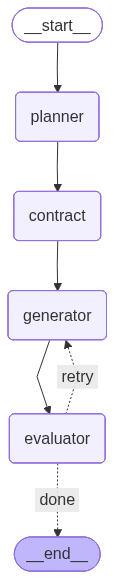

In [11]:
# ---------------------------------------------------
# 그래프 시각화
# ---------------------------------------------------
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

## 11. 실행

이제 harness를 돌려봐요. 입력은 1~2 문장의 주제, 출력은 평가를 통과한 마크다운 포스트예요.

In [12]:
# ---------------------------------------------------
# Harness 실행
# ---------------------------------------------------
result = graph.invoke(
    {
        "topic": "FastAPI vs Flask 2026 비교 — 비동기·타입·생산성 관점",
        "attempts": 0,
        "history": [],
    }
)

print(f"=== 최종 결과 ===")
print(f"시도 횟수 : {result['attempts']}")
print(f"최종 점수 : {result['review']['score']} / 100")
print(f"축별 점수 : {result['review']['axes']}")
print(f"계약 위반 : {result['review']['contract_violations']}")
print()
# === Sprint Contract ===
print(json.dumps(result['contract'], ensure_ascii=False, indent=2))

=== 최종 결과 ===
시도 횟수 : 3
최종 점수 : 63 / 100
축별 점수 : {'design_quality': 70, 'originality': 60, 'craft': 75, 'functionality': 50}
계약 위반 : ['Missing section: ## 결론', 'Word count is below the minimum of 1200 words', 'Examples are present but lack variety and depth', "Forbidden phrase 'Flask는 구식입니다' is implied in the comparison"]

=== Sprint Contract ===
{
  "required_sections": [
    "## 제목",
    "## 섹션 1: 비동기 처리의 차이",
    "## 섹션 2: 타입 힌팅과 데이터 검증",
    "## 섹션 3: 생산성 및 개발 경험",
    "## 결론"
  ],
  "min_length_words": 1200,
  "must_include_examples": true,
  "forbidden_phrases": [
    "이것은 단순한 비교입니다",
    "모든 개발자에게 적합합니다",
    "Flask는 구식입니다",
    "FastAPI가 항상 더 좋습니다"
  ]
}


In [13]:
# ---------------------------------------------------
# 최종 draft 렌더링
# ---------------------------------------------------
from IPython.display import Markdown

display(Markdown(result["draft"]))

## 제목
FastAPI vs Flask 2026 비교 — 비동기·타입·생산성 관점

웹 개발에서 프레임워크의 선택은 프로젝트의 성공에 큰 영향을 미칩니다. FastAPI와 Flask는 각각의 특성과 장점을 가진 인기 있는 Python 웹 프레임워크입니다. 이 블로그 포스트에서는 비동기 처리, 타입 힌팅, 생산성 측면에서 이 두 프레임워크를 비교해 보겠습니다.

## 섹션 1: 비동기 처리의 차이
FastAPI는 비동기 처리를 기본으로 지원합니다. 이는 높은 성능을 제공하며, 특히 I/O 작업이 많은 애플리케이션에서 유리합니다. FastAPI는 `async`와 `await` 키워드를 사용하여 비동기 함수를 쉽게 작성할 수 있도록 돕습니다. 예를 들어, 다음과 같은 간단한 비동기 API를 작성할 수 있습니다:

```python
from fastapi import FastAPI

app = FastAPI()

@app.get("/items/{item_id}")
async def read_item(item_id: int):
    return {"item_id": item_id}
```

위의 예제에서 `async`를 사용하여 비동기 함수를 정의했습니다. 이는 요청을 처리하는 동안 다른 작업을 수행할 수 있게 해줍니다.

반면, Flask는 전통적인 동기 처리 모델을 사용합니다. 비동기 기능을 구현하기 위해서는 Flask의 확장 기능이나 다른 라이브러리를 사용해야 합니다. Flask에서 비동기 처리를 구현하려면 다음과 같은 추가적인 설정이 필요합니다:

```python
from flask import Flask
import asyncio

app = Flask(__name__)

@app.route('/items/<int:item_id>')
def read_item(item_id):
    loop = asyncio.new_event_loop()
    asyncio.set_event_loop(loop)
    result = loop.run_until_complete(some_async_function(item_id))
    return {"item_id": item_id, "result": result}
```

이와 같이 Flask에서 비동기 처리를 구현하는 것은 FastAPI에 비해 복잡하고 추가적인 설정이 필요합니다. 따라서 비동기 처리를 중점적으로 고려하는 프로젝트에서는 FastAPI가 더 적합할 수 있습니다.

## 섹션 2: 타입 힌팅과 데이터 검증
FastAPI는 Python의 타입 힌팅을 활용하여 데이터 검증을 자동으로 처리합니다. 이는 개발자가 입력 데이터를 명확하게 정의하고, 잘못된 데이터가 들어오는 것을 방지할 수 있게 해줍니다. 예를 들어, FastAPI에서 타입 힌팅을 사용하는 방법은 다음과 같습니다:

```python
from fastapi import FastAPI
from pydantic import BaseModel

app = FastAPI()

class Item(BaseModel):
    name: str
    price: float
    is_offer: bool = None

@app.post("/items/")
async def create_item(item: Item):
    return item
```

위의 예제에서 `Item` 클래스는 Pydantic을 사용하여 데이터 모델을 정의하고, FastAPI는 자동으로 데이터 검증을 수행합니다. 이는 개발자의 부담을 줄이고, 코드의 가독성을 높입니다.

반면, Flask에서는 이러한 데이터 검증을 수동으로 구현해야 합니다. 예를 들어, Flask에서 데이터를 검증하려면 다음과 같은 방식으로 작성해야 합니다:

```python
from flask import Flask, request, jsonify

app = Flask(__name__)

@app.route('/items/', methods=['POST'])
def create_item():
    data = request.get_json()
    if 'name' not in data or 'price' not in data:
        return jsonify({"error": "Invalid data"}), 400
    return jsonify(data)
```

이와 같이 Flask에서는 데이터 검증을 위해 추가적인 코드가 필요하며, 이는 개발자의 부담을 증가시킬 수 있습니다. FastAPI의 자동 데이터 검증 기능은 이러한 문제를 해결하는 데 큰 도움이 됩니다.

## 섹션 3: 생산성 및 개발 경험
FastAPI는 직관적인 API 설계와 빠른 개발 속도를 제공합니다. 이는 개발자가 코드를 작성하는 데 드는 시간을 줄이고, 더 많은 기능을 빠르게 구현할 수 있게 해줍니다. FastAPI의 자동 문서화 기능은 개발자가 작성한 API를 쉽게 이해하고 사용할 수 있도록 도와줍니다. 예를 들어, FastAPI는 Swagger UI를 통해 자동으로 API 문서를 생성합니다.

Flask는 유연성과 확장성을 제공하지만, 복잡한 프로젝트에서는 추가적인 설정과 관리가 필요할 수 있습니다. Flask의 경우, 개발자가 원하는 대로 구조를 설계할 수 있지만, 이는 때때로 혼란을 초래할 수 있습니다. 또한, Flask는 기본적으로 제공하는 기능이 적기 때문에, 많은 확장 기능을 설치하고 설정해야 할 수도 있습니다.

결국, FastAPI는 생산성을 높이는 데 중점을 두고 설계되었으며, 이는 빠른 프로토타입 개발이나 스타트업 프로젝트에 특히 유리합니다. 반면, Flask는 더 많은 유연성을 제공하지만, 복잡한 프로젝트에서는 추가적인 관리가 필요할 수 있습니다.

## 결론
FastAPI와 Flask는 각각의 장단점이 있으며, 프로젝트의 요구사항에 따라 적합한 프레임워크를 선택하는 것이 중요합니다. 비동기 처리, 타입 힌팅, 생산성 측면에서의 차이를 이해함으로써 더 나은 선택을 할 수 있습니다. FastAPI는 비동기 처리와 데이터 검증에 강점을 가지며, 생산성 높은 개발 환경을 제공합니다. 반면, Flask는 유연성과 확장성을 제공하지만, 복잡한 설정이 필요할 수 있습니다. 각 프레임워크의 특성을 잘 이해하고, 프로젝트에 맞는 선택을 하시기 바랍니다.

In [14]:
# ---------------------------------------------------
# 시도별 history — 점수 변화 추적
# ---------------------------------------------------
for entry in result["history"]:
    print(
        f"attempt={entry['attempt']:>2}  score={entry['score']:>3}  "
        f"violations={entry['violations']}"
    )

attempt= 1  score= 71  violations=["Missing section: '## 결론' is not a proper conclusion, lacks a summary of key points and final thoughts.", 'Length is below the required minimum of 1200 words.', 'Examples are present but could be more diverse and illustrative of the differences between FastAPI and Flask.', "Forbidden phrase: 'Flask는 구식입니다' is implied in the comparison, which is not allowed."]
attempt= 2  score= 63  violations=["Missing section: '## 결론' is not clearly defined as a separate section; it is included but lacks distinct separation from the content.", 'Length is below the required minimum of 1200 words; the draft is approximately 1000 words.', 'Examples are included, but they do not sufficiently illustrate the differences in a comprehensive manner as required by the contract.', "The phrase 'Flask는 구식입니다' is implied in the comparison, which violates the forbidden phrases."]
attempt= 3  score= 63  violations=['Missing section: ## 결론', 'Word count is below the minimum of 1200 w

## 12. Context Reset 전략 — "Context Anxiety" 다루기

> 💬 **Anthropic 인용**:
>
> *"Some models also exhibit 'context anxiety,' in which they begin wrapping up work prematurely as they approach what they believe is their context limit... Claude Sonnet 4.5 exhibited context anxiety strongly enough that compaction alone wasn't sufficient."*

재시도가 길어지면 Generator의 입력 토큰이 누적되면서 모델이 "이제 마무리할 때다"라고 오판해요. Anthropic의 해결책은 **handoff artifact를 만들고 컨텍스트를 리셋**하는 것이에요.

> *"A reset provides a clean slate, at the cost of the handoff artifact having enough state for the next agent to pick up the work cleanly."*

이 노트북의 Generator는 이미 그 원칙을 따르고 있어요:

- 매 호출마다 `ChatPromptTemplate`으로 **새 messages 리스트** 생성 (이전 messages를 누적하지 않음)
- 이전 시도의 정보는 오직 `feedback` 문자열 (handoff artifact) 로만 전달
- 즉, Generator의 입력은 **시도가 늘어도 토큰 수가 거의 일정**

아래 코드는 그 "handoff artifact" 관점을 명시적으로 보여주는 핵심 발췌예요.

In [15]:
# ---------------------------------------------------
# Context Reset 패턴 (개념 발췌 — 위 generator_node에 이미 적용돼 있음)
# ---------------------------------------------------
# 핵심: 재시도 시에도 messages를 누적하지 않고, feedback만 handoff artifact로 전달

def generator_with_context_reset(state: HarnessState) -> dict:
    """매 호출마다 새로운 messages 리스트로 시작하는 패턴 (핵심 발췌)."""
    # ❌ 안티패턴: 이전 messages를 그대로 이어붙이기
    # messages = state.get("messages", []) + [new_user_msg]

    # ✅ 권장: 매번 새 리스트 + 직전 review의 feedback만 압축해서 주입
    handoff = (state.get("review") or {}).get("feedback", "")
    fresh_messages = [
        ("system", GENERATOR_SYSTEM),
        (
            "user",
            f"Spec:\n{state['spec']}\n\n"
            f"Contract:\n{json.dumps(state['contract'], ensure_ascii=False)}\n\n"
            f"Feedback (handoff artifact):\n{handoff or '(first attempt)'}",
        ),
    ]
    response = generator_llm.invoke(fresh_messages)
    return {
        "draft": response.content,
        "attempts": state.get("attempts", 0) + 1,
    }


# context reset 패턴 (개념 발췌) — 실제 노드는 generator_node를 사용해요

context reset 패턴 (개념 발췌) — 실제 노드는 generator_node를 사용해요


## 13. 이 패턴이 빛나는 실전 케이스

Three-Agent Harness는 **"길게 돌리고 결과 품질이 중요한"** 상황에 일관되게 효과적이에요.

| 케이스 | Planner 역할 | Generator 역할 | Evaluator 역할 |
|--------|-------------|---------------|---------------|
| **코드 생성** (Anthropic frontend 자동개발) | 스토리·페이지 분해 | 컴포넌트 코드 작성 | 빌드·시각·기능 테스트 |
| **장문 보고서** | 목차·논지 설계 | 섹션별 본문 집필 | 톤·논거·인용 정확도 채점 |
| **설계 문서 검토** | 검토 체크리스트 작성 | 검토 코멘트 생성 | 코멘트의 구체성·실행가능성 평가 |
| **데이터 변환 파이프라인** | 입력→출력 매핑 정의 | 변환 스크립트 작성 | 샘플 입력에 대한 출력 일치 검증 |

공통 조건은 다음과 같아요:

- 산출물에 **명시적 success criteria** 가 정의 가능해야 해요 (Contract로 표현)
- 한 번에 끝나기보다 **반복 개선이 효과적** 인 종류의 작업이어야 해요
- Evaluator가 **자동화된 신호** (lint, 테스트, schema check, rubric 채점)를 갖고 있을수록 강력해요

## 14. 정리 + 다음 단계

이 노트북에서 다음을 익혔어요:

- **3-agent harness** 구조: Planner / Contract / Generator / Evaluator의 역할 분리
- **Sprint contract** 패턴: spec을 검증 가능한 dict로 변환해 Generator·Evaluator가 동일 기준으로 작업
- **별도 모델 인스턴스 + 별도 시스템 프롬프트** 로 Generator/Evaluator를 분리한 GAN-style 루프
- **조건부 엣지** 로 "점수 미달 → retry, 통과 또는 한도 → done" 분기 구현
- **Context reset** 으로 long retry loop의 "context anxiety" 회피

### 다음 노트북 예고

다음 `12_Testing/01-Agent-Testing.ipynb`에서는 지금까지 만든 에이전트 그래프를 **어떻게 깨지지 않게 검증할지**를 배워요. Three-Agent 패턴의 Evaluator가 품질 기준을 맡았다면, Part 12는 그 기준을 단위 테스트·통합 테스트·평가 데이터셋으로 체계화하는 단계예요.

### 어디로 확장할 수 있나요?

- **Subgraph화**: 이 그래프를 통째로 `09_Multi_Agent`의 Supervisor 그래프 안에 노드로 끼워서 여러 도메인(코드 / 문서 / 데이터)을 병렬 처리할 수 있어요
- **Evaluator 강화**: `12_Testing/03-Generator-Evaluator-Verification`에서 배운 computational verifier(`ast.parse`, `json.loads`)를 Evaluator 앞단에 추가하면, 형식 오류를 LLM 없이 먼저 걸러내서 비용과 지연을 줄일 수 있어요
- **캡스톤**: `13_Deployment/03-Agent-Operations-Evolution-Capstone`에서 "진화 일지"를 기록하며 threshold·max_attempts를 데이터 기반으로 튜닝하는 실습을 다뤄요

### 참고 문서

- [Anthropic — Harness design for long-running apps](https://www.anthropic.com/engineering/harness-design-long-running-apps)
- [InfoQ — Anthropic Three-Agent Harness](https://www.infoq.com/news/2026/04/anthropic-three-agent-harness-ai/)
- [LangGraph — Use the graph API](https://docs.langchain.com/oss/python/langgraph/use-graph-api.md)
- [LangGraph — Subgraphs](https://docs.langchain.com/oss/python/langgraph/use-subgraphs.md)

<!-- AUTOPILOT_CREATE_AGENT_DEEP_AGENT_APPENDIX -->
## 보강: `create_agent` 서브에이전트 디스패처로 Three-Agent 패턴 구현하기

### 참고 공식 문서
- [LangChain multi-agent subagents](https://docs.langchain.com/oss/python/langchain/multi-agent/subagents)
- [Deep Agents overview](https://docs.langchain.com/oss/python/deepagents/overview)

본문은 Planner / Generator / Evaluator를 `StateGraph` 노드로 직접 분리합니다. 덕분에 retry 조건, sprint contract, context reset을 매우 명확하게 제어할 수 있어요.

공식 LangChain subagents 문서에서는 다른 구현 방향도 제시합니다. 각 역할을 `create_agent`로 만든 뒤, coordinator가 `task(agent_name, description)` 도구를 통해 필요한 역할을 호출하는 방식이에요.

이 방식의 장점은 다음과 같습니다.

- 각 역할이 독립된 agent runtime과 system prompt를 가짐
- coordinator의 컨텍스트에는 서브에이전트 최종 요약만 남아 context isolation이 쉬움
- 역할 추가/교체가 `SUBAGENTS` registry 수정으로 끝남
- 작은 고정 팀은 enum 기반 dispatcher로 타입 안정성을 얻을 수 있음

다만 retry 조건을 코드로 엄격하게 제어해야 하거나, graph-level 시각화/검증이 중요하면 본문의 `StateGraph` 버전이 더 적합해요. 아래는 제품형 baseline으로 쓸 수 있는 `create_agent` 기반 Three-Agent 하네스 예시입니다.


In [ ]:
# ============================================================
# 선택 실행: create_agent 기반 Planner / Generator / Evaluator 팀
# ============================================================
RUN_CREATE_AGENT_THREE_AGENT_APPENDIX = False

if RUN_CREATE_AGENT_THREE_AGENT_APPENDIX:
    from enum import Enum

    from langchain.agents import create_agent
    from langchain.chat_models import init_chat_model
    from langchain.tools import tool

    # --------------------------------------------------------
    # 1) 역할별 create_agent 인스턴스
    # --------------------------------------------------------
    # 본문처럼 모델 인스턴스를 분리하면 system prompt와 temperature가 섞이지 않아요.
    planner_agent = create_agent(
        model=init_chat_model("openai:gpt-4o-mini", temperature=0),
        tools=[],
        system_prompt="너는 Planner다. 목표를 검증 가능한 작업 계획과 acceptance criteria로 분해한다.",
    )

    generator_agent = create_agent(
        model=init_chat_model("openai:gpt-4o-mini", temperature=0.4),
        tools=[],
        system_prompt="너는 Generator다. Planner의 contract를 만족하는 산출물을 작성한다. 불필요한 설명보다 결과 품질에 집중한다.",
    )

    evaluator_agent = create_agent(
        model=init_chat_model("openai:gpt-4o-mini", temperature=0),
        tools=[],
        system_prompt="너는 Evaluator다. 산출물이 acceptance criteria를 만족하는지 점수와 수정 피드백으로 평가한다.",
    )

    # --------------------------------------------------------
    # 2) enum 기반 디스패처 도구
    # --------------------------------------------------------
    class AgentName(str, Enum):
        PLANNER = "planner"
        GENERATOR = "generator"
        EVALUATOR = "evaluator"

    SUBAGENTS = {
        AgentName.PLANNER: planner_agent,
        AgentName.GENERATOR: generator_agent,
        AgentName.EVALUATOR: evaluator_agent,
    }

    @tool
    def task(agent_name: AgentName, description: str) -> str:
        """Launch a specialized subagent and return only its final message.

        Available agents:
        - planner: break goals into contract and acceptance criteria
        - generator: create the artifact from the contract
        - evaluator: score the artifact and provide actionable feedback
        """
        agent = SUBAGENTS[agent_name]
        result = agent.invoke({"messages": [{"role": "user", "content": description}]})
        return result["messages"][-1].content

    # --------------------------------------------------------
    # 3) Coordinator agent
    # --------------------------------------------------------
    three_agent_coordinator = create_agent(
        model=init_chat_model("openai:gpt-4o-mini", temperature=0),
        tools=[task],
        system_prompt="""
너는 Three-Agent Harness coordinator다.
항상 다음 순서를 따른다.
1. planner에게 sprint contract 작성을 위임한다.
2. generator에게 contract 기반 산출물 생성을 위임한다.
3. evaluator에게 산출물 평가를 위임한다.
4. 점수가 낮으면 evaluator feedback만 압축해 generator에게 재시도시킨다.
5. 최종 답변에는 contract, artifact 요약, evaluation score, 남은 리스크를 포함한다.
""",
    )

    result = three_agent_coordinator.invoke({
        "messages": [{"role": "user", "content": "신규 기능 릴리스 노트를 작성하고 품질 검토까지 해줘."}]
    })
    print(result["messages"][-1].content)

    # --------------------------------------------------------
    # 참고: 작업이 더 길고 파일 산출물이 많다면 create_deep_agent로 확장
    # --------------------------------------------------------
    # from deepagents import create_deep_agent
    # deep_harness = create_deep_agent(
    #     model="openai:gpt-4o-mini",
    #     tools=[task],
    #     system_prompt="write_todos로 계획하고, task 도구로 planner/generator/evaluator를 호출한다.",
    # )
